# HistGradientBoostingRegressor TUO — versão horária completa

Este notebook expande a configuração `hgb_B`, selecionada na triagem de 2024, para os **48 estimadores** necessários à previsão direta de temperatura e umidade entre `t+1` e `t+24`.

## Protocolo congelado

- Atributos: TUO.
- Processamento: CPU.
- Um estimador por combinação `horizonte × alvo`.
- Treino: 2011–2023, excluindo 2022.
- Hiperparâmetros: `hgb_B`, já selecionados com 2024.
- Validação: 2024.
- Teste fechado: 2025.
- Avaliação adicional: 2026 parcial.
- Sem covariáveis meteorológicas futuras reais.
- Alvos treinados e avaliados em °C e pontos percentuais.

Não há nova busca de hiperparâmetros neste notebook. Isso evita reutilizar 2024 indefinidamente e preserva 2025 como teste final.

## 1. Importações e configuração

In [1]:
from pathlib import Path
import json
import platform
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns",100)
pd.set_option("display.width",180)

DIRETORIO_TUO=Path("dados_processados_multivariados/TUO")
DIRETORIO_RIDGE=Path("resultados_modelagem/ablacao_ridge_TU_TUO_TUOV")
DIRETORIO_TRIAGEM=Path("resultados_modelagem/hist_gradient_boosting_TUO_screening")
DIRETORIO_SAIDA=Path("resultados_modelagem/hist_gradient_boosting_TUO_48")
DIRETORIO_MODELOS=DIRETORIO_SAIDA/"modelos"
DIRETORIO_SAIDA.mkdir(parents=True,exist_ok=True)
DIRETORIO_MODELOS.mkdir(parents=True,exist_ok=True)

SPLITS=["treino","validacao","teste","avaliacao_2026"]
HORIZONTES=list(range(1,25))
ALVOS={0:("temperatura_c","°C"),1:("umidade_pct","p.p.")}
SEMENTE=42

HGB_B={
 "loss":"squared_error","learning_rate":0.05,"max_iter":250,
 "max_leaf_nodes":31,"min_samples_leaf":30,"l2_regularization":1.0,
 "early_stopping":True,"validation_fraction":0.1,
 "n_iter_no_change":15,"tol":1e-5,"random_state":SEMENTE,
}

print("Dispositivo: CPU")
print("Estimadores a treinar:",len(HORIZONTES)*len(ALVOS))
print("Configuração congelada: hgb_B")

Dispositivo: CPU
Estimadores a treinar: 48
Configuração congelada: hgb_B


## 2. Verificação da decisão da triagem

In [2]:
caminho_meta_triagem=DIRETORIO_TRIAGEM/"metadados_hgb.json"
if not caminho_meta_triagem.exists(): raise FileNotFoundError(f"Metadados da triagem não encontrados: {caminho_meta_triagem}")
with caminho_meta_triagem.open(encoding="utf-8") as f: meta_triagem=json.load(f)
assert meta_triagem["melhor_configuracao_hgb"]=="hgb_B"
assert meta_triagem["expandir_para_48_modelos"] is True
assert meta_triagem["configuracao_atributos"]=="TUO"
print("Triagem confirmada:",meta_triagem)

Triagem confirmada: {'modelo': 'HistGradientBoostingRegressor', 'configuracao_atributos': 'TUO', 'melhor_configuracao_hgb': 'hgb_B', 'horizontes_triagem': [1, 3, 6, 12, 24], 'expandir_para_48_modelos': True, 'ganho_medio_mae_validacao_pct': 4.959722108607968, 'combinacoes_com_ganho': 8, 'usa_covariaveis_meteorologicas_futuras': False, 'processamento': 'CPU', 'versoes': {'python': '3.12.14', 'numpy': '2.5.2', 'pandas': '3.0.5', 'plataforma': 'Windows-11-10.0.26200-SP0'}}


## 3. Carregamento dos dados TUO e da Ridge de referência

In [3]:
obrigatorios=[DIRETORIO_TUO/f"{s}.npz" for s in SPLITS]+[DIRETORIO_TUO/"scaler_y.joblib",DIRETORIO_TUO/"metadados.json",DIRETORIO_RIDGE/"modelo_ridge_TUO.joblib"]
faltantes=[str(x) for x in obrigatorios if not x.exists()]
if faltantes: raise FileNotFoundError("Arquivos ausentes:"+chr(10)+chr(10).join(faltantes))

splits={}
for s in SPLITS:
 with np.load(DIRETORIO_TUO/f"{s}.npz") as arq: splits[s]={k:arq[k] for k in arq.files}
scaler_y=joblib.load(DIRETORIO_TUO/"scaler_y.joblib")
modelo_ridge=joblib.load(DIRETORIO_RIDGE/"modelo_ridge_TUO.joblib")
with (DIRETORIO_TUO/"metadados.json").open(encoding="utf-8") as f: meta_preparacao=json.load(f)
assert meta_preparacao["usa_covariaveis_meteorologicas_futuras"] is False
print(meta_preparacao["contagens"])

{'treino': 84744, 'validacao': 7837, 'teste': 7970, 'avaliacao_2026': 4551}


## 4. Preparação da matriz tabular e dos alvos reais

In [4]:
def preparar_X(split):
 hist=split["X_historico"].reshape(len(split["X_historico"]),-1)
 fut=split["X_futuro_temporal"].reshape(len(split["X_futuro_temporal"]),-1)
 return np.concatenate([hist,fut],axis=1).astype(np.float32,copy=False)

def inverter_y(y_norm):
 forma=y_norm.shape
 return scaler_y.inverse_transform(y_norm.reshape(-1,2)).reshape(forma)

X={s:preparar_X(splits[s]) for s in SPLITS}
y={s:inverter_y(splits[s]["y"]) for s in SPLITS}
assert X["treino"].shape[1]==264
assert all(np.isfinite(X[s]).all() and np.isfinite(y[s]).all() for s in SPLITS)
for s in SPLITS: print(s,X[s].shape,y[s].shape)

treino (84744, 264) (84744, 24, 2)
validacao (7837, 264) (7837, 24, 2)
teste (7970, 264) (7970, 24, 2)
avaliacao_2026 (4551, 264) (4551, 24, 2)


## 5. Treinamento dos 48 estimadores

Cada estimador é salvo imediatamente após o treinamento. Se a execução for interrompida, defina `REUTILIZAR_MODELOS_EXISTENTES = True` e execute novamente para continuar a partir dos arquivos já concluídos.

In [5]:
REUTILIZAR_MODELOS_EXISTENTES=True
modelos={}; log_treino=[]
total=len(HORIZONTES)*len(ALVOS); contador=0; inicio_total=time.perf_counter()

for h in HORIZONTES:
 hi=h-1
 for j,(alvo,unidade) in ALVOS.items():
  contador+=1; caminho=DIRETORIO_MODELOS/f"hgb_TUO_{alvo}_h{h:02d}.joblib"
  if REUTILIZAR_MODELOS_EXISTENTES and caminho.exists():
   modelo=joblib.load(caminho); origem="carregado"
   print(f"[{contador:02d}/{total}] Carregado {alvo} t+{h}")
   tempo=0.0
  else:
   print(f"[{contador:02d}/{total}] Treinando {alvo} t+{h}...")
   modelo=HistGradientBoostingRegressor(**HGB_B)
   t0=time.perf_counter(); modelo.fit(X["treino"],y["treino"][:,hi,j]); tempo=time.perf_counter()-t0
   joblib.dump(modelo,caminho); origem="treinado"
   print(f"    concluído em {tempo:.1f}s | iterações={modelo.n_iter_}")
  modelos[(h,j)]=modelo
  pred_tr=modelo.predict(X["treino"]); pred_val=modelo.predict(X["validacao"])
  log_treino.append({"horizonte_horas":h,"indice_alvo":j,"alvo":alvo,"unidade":unidade,"origem":origem,
   "tempo_segundos":tempo,"n_iter_":modelo.n_iter_,
   "mae_treino":mean_absolute_error(y["treino"][:,hi,j],pred_tr),
   "mae_validacao":mean_absolute_error(y["validacao"][:,hi,j],pred_val)})

log_treino=pd.DataFrame(log_treino)
print(f"Etapa concluída em {(time.perf_counter()-inicio_total)/60:.2f} minutos")
display(log_treino)

[01/48] Treinando temperatura_c t+1...
    concluído em 8.9s | iterações=250
[02/48] Treinando umidade_pct t+1...
    concluído em 9.3s | iterações=246
[03/48] Treinando temperatura_c t+2...
    concluído em 9.0s | iterações=250
[04/48] Treinando umidade_pct t+2...
    concluído em 8.5s | iterações=250
[05/48] Treinando temperatura_c t+3...
    concluído em 8.5s | iterações=250
[06/48] Treinando umidade_pct t+3...
    concluído em 8.8s | iterações=250
[07/48] Treinando temperatura_c t+4...
    concluído em 9.0s | iterações=250
[08/48] Treinando umidade_pct t+4...
    concluído em 8.6s | iterações=250
[09/48] Treinando temperatura_c t+5...
    concluído em 8.9s | iterações=250
[10/48] Treinando umidade_pct t+5...
    concluído em 8.9s | iterações=250
[11/48] Treinando temperatura_c t+6...
    concluído em 8.8s | iterações=250
[12/48] Treinando umidade_pct t+6...
    concluído em 8.9s | iterações=250
[13/48] Treinando temperatura_c t+7...
    concluído em 9.0s | iterações=250
[14/48] Tre

,horizonte_horas,indice_alvo,alvo,unidade,origem,tempo_segundos,n_iter_,mae_treino,mae_validacao
0,1,0,temperatura_c,°C,treinado,8.942595,250,0.443627,0.522882
1,1,1,umidade_pct,p.p.,treinado,9.307087,246,2.324674,2.496752
2,2,0,temperatura_c,°C,treinado,9.037595,250,0.641150,0.758135
3,2,1,umidade_pct,p.p.,treinado,8.533779,250,3.378059,3.676619
4,3,0,temperatura_c,°C,treinado,8.536614,250,0.795560,0.947242
5,3,1,umidade_pct,p.p.,treinado,8.829281,250,4.134122,4.625169
6,4,0,temperatura_c,°C,treinado,8.986336,250,0.919130,1.112388
7,4,1,umidade_pct,p.p.,treinado,8.564480,250,4.726725,5.387857
8,5,0,temperatura_c,°C,treinado,8.949491,250,1.018012,1.232506
9,5,1,umidade_pct,p.p.,treinado,8.870442,250,5.168802,5.993511


## 6. Previsão horária completa

In [6]:
def prever_hgb(X_split):
 saida=np.empty((len(X_split),24,2),dtype=np.float32)
 for h in HORIZONTES:
  for j in ALVOS: saida[:,h-1,j]=modelos[(h,j)].predict(X_split).astype(np.float32)
 return saida

def prever_ridge(X_split):
 pred_norm=modelo_ridge.predict(X_split).reshape(-1,24,2)
 return inverter_y(pred_norm).astype(np.float32)

previsoes={}
for s in ["validacao","teste","avaliacao_2026"]:
 previsoes[s]={"hgb":prever_hgb(X[s]),"ridge":prever_ridge(X[s]),"real":y[s].astype(np.float32)}
 print(s,previsoes[s]["hgb"].shape)

validacao (7837, 24, 2)
teste (7970, 24, 2)
avaliacao_2026 (4551, 24, 2)


## 7. Métricas por horizonte e globais

In [7]:
linhas=[]
for s,conteudo in previsoes.items():
 for nome in ["ridge","hgb"]:
  pred=conteudo[nome]; real=conteudo["real"]
  for h in HORIZONTES:
   for j,(alvo,unidade) in ALVOS.items():
    r=real[:,h-1,j]; p=pred[:,h-1,j]
    linhas.append({"modelo":nome,"split":s,"horizonte_horas":h,"alvo":alvo,"unidade":unidade,
     "mae":mean_absolute_error(r,p),"rmse":mean_squared_error(r,p)**0.5,"vies":float(np.mean(p-r)),"n":len(r)})
metricas_horizonte=pd.DataFrame(linhas)

globais=[]
for (modelo,split,alvo,unidade),g in metricas_horizonte.groupby(["modelo","split","alvo","unidade"]):
 j=0 if alvo=="temperatura_c" else 1
 real=previsoes[split]["real"][:,:,j].ravel(); pred=previsoes[split][modelo][:,:,j].ravel()
 globais.append({"modelo":modelo,"split":split,"alvo":alvo,"unidade":unidade,
  "mae_global_1a24":mean_absolute_error(real,pred),"rmse_global_1a24":mean_squared_error(real,pred)**0.5,
  "vies_global_1a24":float(np.mean(pred-real)),"n_previsoes":len(real)})
metricas_globais=pd.DataFrame(globais)
display(metricas_globais.sort_values(["split","alvo","modelo"]).reset_index(drop=True))

,modelo,split,alvo,unidade,mae_global_1a24,rmse_global_1a24,vies_global_1a24,n_previsoes
0,hgb,avaliacao_2026,temperatura_c,°C,1.386547,1.946017,-0.010110,109224
1,ridge,avaliacao_2026,temperatura_c,°C,1.509436,2.120637,0.047108,109224
2,hgb,avaliacao_2026,umidade_pct,p.p.,7.043255,9.923275,-1.024050,109224
3,ridge,avaliacao_2026,umidade_pct,p.p.,7.308827,10.249426,-1.239488,109224
4,hgb,teste,temperatura_c,°C,1.576896,2.260600,0.029616,191280
5,ridge,teste,temperatura_c,°C,1.689248,2.395614,0.041565,191280
6,hgb,teste,umidade_pct,p.p.,7.979404,11.445583,-0.552358,191280
7,ridge,teste,umidade_pct,p.p.,8.222882,11.613235,-0.569547,191280
8,hgb,validacao,temperatura_c,°C,1.613582,2.217067,-0.276422,188088
9,ridge,validacao,temperatura_c,°C,1.683895,2.310486,-0.217981,188088


## 8. Ganho completo do HGB sobre a Ridge

In [8]:
r=metricas_horizonte[metricas_horizonte.modelo=="ridge"].set_index(["split","horizonte_horas","alvo"])
h=metricas_horizonte[metricas_horizonte.modelo=="hgb"].set_index(["split","horizonte_horas","alvo"])
comp=[]
for idx in r.index:
 comp.append({"split":idx[0],"horizonte_horas":idx[1],"alvo":idx[2],"unidade":r.loc[idx,"unidade"],
  "mae_ridge":r.loc[idx,"mae"],"mae_hgb":h.loc[idx,"mae"],"ganho_mae_hgb_pct":100*(r.loc[idx,"mae"]-h.loc[idx,"mae"])/r.loc[idx,"mae"],
  "rmse_ridge":r.loc[idx,"rmse"],"rmse_hgb":h.loc[idx,"rmse"],"ganho_rmse_hgb_pct":100*(r.loc[idx,"rmse"]-h.loc[idx,"rmse"])/r.loc[idx,"rmse"]})
comparacao=pd.DataFrame(comp)
resumo_ganhos=(comparacao.groupby(["split","alvo"])[["ganho_mae_hgb_pct","ganho_rmse_hgb_pct"]].mean().reset_index())
display(resumo_ganhos)

,split,alvo,ganho_mae_hgb_pct,ganho_rmse_hgb_pct
0,avaliacao_2026,temperatura_c,8.802718,8.901917
1,avaliacao_2026,umidade_pct,4.023041,3.713876
2,teste,temperatura_c,7.423995,6.668418
3,teste,umidade_pct,3.385709,2.013342
4,validacao,temperatura_c,4.896253,4.763963
5,validacao,umidade_pct,2.645962,2.779214


## 9. Gráficos por horizonte

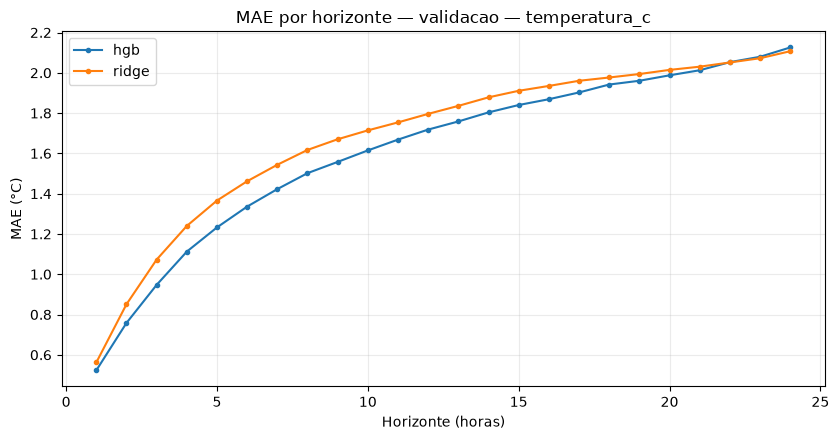

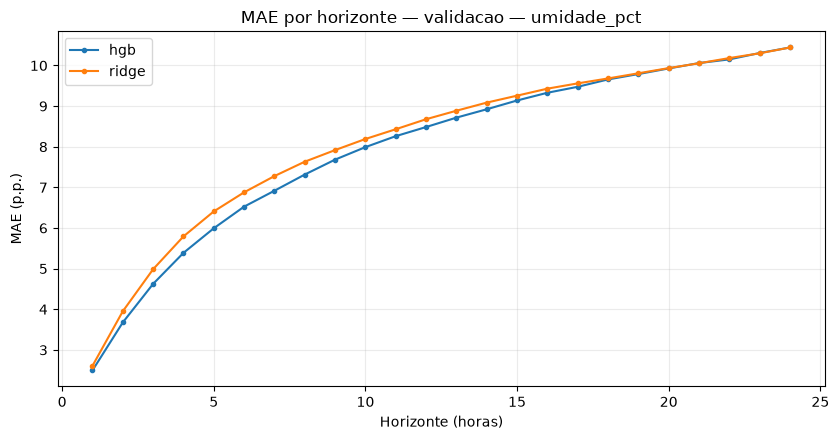

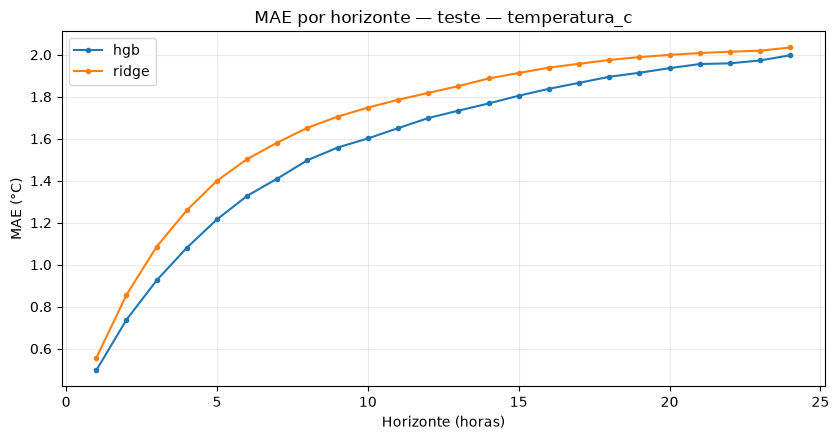

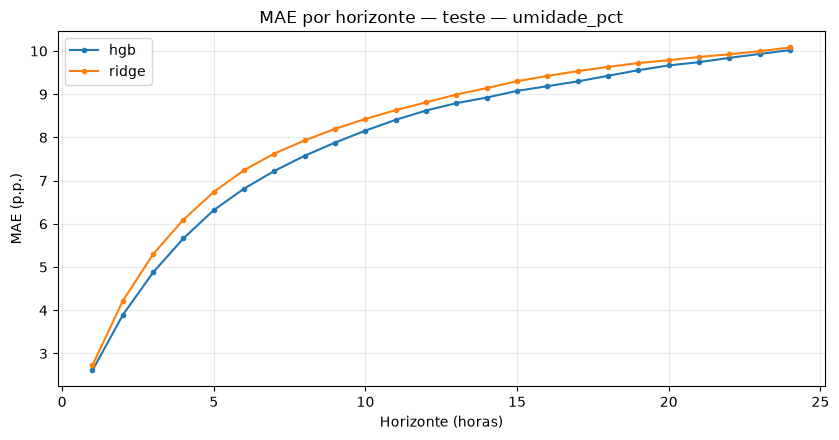

In [9]:
for split in ["validacao","teste"]:
 for alvo in ["temperatura_c","umidade_pct"]:
  d=metricas_horizonte[(metricas_horizonte.split==split)&(metricas_horizonte.alvo==alvo)]
  fig,ax=plt.subplots(figsize=(8.5,4.5))
  for modelo,g in d.groupby("modelo"): ax.plot(g.horizonte_horas,g.mae,marker="o",markersize=3,label=modelo)
  unidade="°C" if alvo=="temperatura_c" else "p.p."
  ax.set(title=f"MAE por horizonte — {split} — {alvo}",xlabel="Horizonte (horas)",ylabel=f"MAE ({unidade})")
  ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

## 10. Pacote para inferência da futura API

O pacote contém os 48 estimadores, a ordem das entradas, os normalizadores e os metadados necessários para reconstruir a previsão. A API continuará usando CPU.

In [10]:
pacote={
 "modelos":modelos,"configuracao":"TUO","hiperparametros":HGB_B,"tau":24,"horizonte":24,
 "alvos":ALVOS,"metadados_preparacao":meta_preparacao,"scaler_y":scaler_y,
 "usa_covariaveis_meteorologicas_futuras":False,"dispositivo_inferencia":"cpu",
}
joblib.dump(pacote,DIRETORIO_SAIDA/"pacote_hgb_TUO_48_api.joblib",compress=3)
print("Pacote salvo:",DIRETORIO_SAIDA/"pacote_hgb_TUO_48_api.joblib")

Pacote salvo: resultados_modelagem\hist_gradient_boosting_TUO_48\pacote_hgb_TUO_48_api.joblib


## 11. Salvamento de resultados e verificação final

In [11]:
log_treino.to_csv(DIRETORIO_SAIDA/"log_treinamento_48.csv",index=False,encoding="utf-8-sig")
metricas_horizonte.to_csv(DIRETORIO_SAIDA/"metricas_por_horizonte_48.csv",index=False,encoding="utf-8-sig")
metricas_globais.to_csv(DIRETORIO_SAIDA/"metricas_globais_48.csv",index=False,encoding="utf-8-sig")
comparacao.to_csv(DIRETORIO_SAIDA/"comparacao_hgb_ridge_48.csv",index=False,encoding="utf-8-sig")
resumo_ganhos.to_csv(DIRETORIO_SAIDA/"resumo_ganhos_48.csv",index=False,encoding="utf-8-sig")
for s,c in previsoes.items():
 np.savez_compressed(DIRETORIO_SAIDA/f"previsoes_{s}.npz",y_real=c["real"],y_pred_hgb=c["hgb"],y_pred_ridge=c["ridge"],inicio_previsao=splits[s]["inicio_previsao"])
meta={"modelo":"HistGradientBoostingRegressor","configuracao":"TUO","versao":"48_estimadores_horarios",
 "hiperparametros":HGB_B,"treino":"2011-2023, excluindo 2022","validacao":2024,"teste":2025,"avaliacao_adicional":"2026 parcial",
 "usa_covariaveis_meteorologicas_futuras":False,"processamento_treino":"CPU","processamento_inferencia":"CPU",
 "arquitetura_saida":"24 horizontes x 2 alvos","versoes":{"python":sys.version.split()[0],"numpy":np.__version__,"pandas":pd.__version__,"plataforma":platform.platform()}}
with (DIRETORIO_SAIDA/"metadados_modelo_48.json").open("w",encoding="utf-8") as f: json.dump(meta,f,ensure_ascii=False,indent=2)
assert len(modelos)==48
assert np.isfinite(metricas_horizonte[["mae","rmse","vies"]].to_numpy()).all()
assert (DIRETORIO_SAIDA/"pacote_hgb_TUO_48_api.joblib").exists()
assert meta["usa_covariaveis_meteorologicas_futuras"] is False
print("VERIFICAÇÃO FINAL: OK")
print("48 estimadores treinados/carregados:",len(modelos))
display(metricas_globais.sort_values(["split","alvo","modelo"]).reset_index(drop=True))

VERIFICAÇÃO FINAL: OK
48 estimadores treinados/carregados: 48


,modelo,split,alvo,unidade,mae_global_1a24,rmse_global_1a24,vies_global_1a24,n_previsoes
0,hgb,avaliacao_2026,temperatura_c,°C,1.386547,1.946017,-0.010110,109224
1,ridge,avaliacao_2026,temperatura_c,°C,1.509436,2.120637,0.047108,109224
2,hgb,avaliacao_2026,umidade_pct,p.p.,7.043255,9.923275,-1.024050,109224
3,ridge,avaliacao_2026,umidade_pct,p.p.,7.308827,10.249426,-1.239488,109224
4,hgb,teste,temperatura_c,°C,1.576896,2.260600,0.029616,191280
5,ridge,teste,temperatura_c,°C,1.689248,2.395614,0.041565,191280
6,hgb,teste,umidade_pct,p.p.,7.979404,11.445583,-0.552358,191280
7,ridge,teste,umidade_pct,p.p.,8.222882,11.613235,-0.569547,191280
8,hgb,validacao,temperatura_c,°C,1.613582,2.217067,-0.276422,188088
9,ridge,validacao,temperatura_c,°C,1.683895,2.310486,-0.217981,188088


## Encerramento

Após a revisão dos resultados completos, o próximo passo será implementar a GRU direta multialvo em PyTorch com CUDA para treinamento e CPU para inferência. A comparação final incluirá Ridge, HGB e GRU sob o mesmo protocolo temporal.